# Contrast limits with Ruffio method

Suppose you have a non-detection; or suppose you have a detection of a point source very accurately, and you can subtract that signal off the visibilities and you want to know if there is anything *else* in the data. How can you quantify what your detection limits would have been?

There are two methods widely in use in interferometry and this tutorial covers both of them:

- the [Ruffio method](https://ui.adsabs.harvard.edu/abs/2018AJ....156..196R/abstract), which is Bayesian. This calculates the posterior distribution for flux of a point source companion everywhere in a grid using the Laplace approximation, and uses this to put a posterior Nσ upper limit on any flux.
- the [Absil method](https://ui.adsabs.harvard.edu/abs/2011A%26A...535A..68A/abstract), which is frequentist, and relies on $\chi^2$ statistics to put a confidence interval on the data and report an upper limit.

In this tutorial we'll work through applying both methods to a nondetection.

First, let's import everything we need.

In [1]:
import sys
from pathlib import Path

import jax.numpy as jnp
import numpy as onp
import jax.scipy as jsp
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from virgil.grid_fit import laplace_flux_uncertainty_grid, optimized_flux_grid
from virgil.limits import absil_limits, flux_to_delta_mag, ruffio_upperlimit
from virgil.models import BinaryModelCartesian
from virgil.oidata import OIData
from virgil.plotting import plot_contrast_curve, plot_grid_map, set_style

set_style()  # the figure style used throughout the docs

## Simulate Data

Now we will generate some synthetic data from pure noise, using a Fourier sampling similar to the JWST AMI mask.

In [2]:
rng = onp.random.default_rng(7)

oidata = OIData(repo_root / "data" / "NuHor_F480M.oifits")

# Pure-noise injection amplitude (1.0 uses nominal OIData uncertainties).
noise_amp = 1.0

sim_data = {
    "u": oidata.u,
    "v": oidata.v,
    "wavel": oidata.wavel,
    "vis": jnp.ones_like(oidata.vis)
    + noise_amp * jnp.array(rng.normal(size=oidata.vis.shape)) * oidata.d_vis,
    "d_vis": oidata.d_vis,
    "phi": noise_amp
    * jnp.array(rng.normal(size=oidata.phi.shape))
    * oidata.d_phi,
    "d_phi": oidata.d_phi,
    "i_cps1": oidata.i_cps1,
    "i_cps2": oidata.i_cps2,
    "i_cps3": oidata.i_cps3,
    "v2_flag": oidata.v2_flag,
    "cp_flag": oidata.cp_flag,
}

oidata_sim = OIData(sim_data)

print(
    "Noise amplitude: {:.2g}, Vis std: {:.2g}, Phi std: {:.2g}".format(
        noise_amp,
        float(jnp.std(sim_data["vis"] - 1.0)),
        float(jnp.std(sim_data["phi"])),
    )
)

Noise amplitude: 1, Vis std: 0.00033, Phi std: 0.00028


## Declare a search grid

Next we declare the grid over which we're going to search for companions, and we will use this to initialize the flux level in each grid pixel around which we are going to expand the posterior / come up with confidence intervals. 

In [3]:
samples = {
    "dra": jnp.linspace(-250.0, 250.0, 61),
    "ddec": jnp.linspace(-250.0, 250.0, 61),
    "flux": 10 ** jnp.linspace(-5.0, -1.5, 50),
}

# Best-fit companion/primary flux at every (dra, ddec).
opt_flux = optimized_flux_grid(BinaryModelCartesian, oidata_sim, samples)

/var/tmp/jobfs/virgil/src/virgil/_deprecate.py:150: RuntimeWarning: optimized_flux_grid(): the optimizer did not converge at 1 of 3721 grid positions; values there may be inaccurate.
  return fn(*args, **kwargs)


## Ruffio Contrast Limits

The [Ruffio et al 2018](https://ui.adsabs.harvard.edu/abs/2018AJ....156..196R/abstract) method for contrast limits is Bayesian - you infer the Gaussian posterior on flux of a companion, and impose a prior that the flux is positive. Then you report a chosen percentile of this as the flux upper limit for a nondetection, *conditioned on this being the correct astrometry and there being a real source there*. 

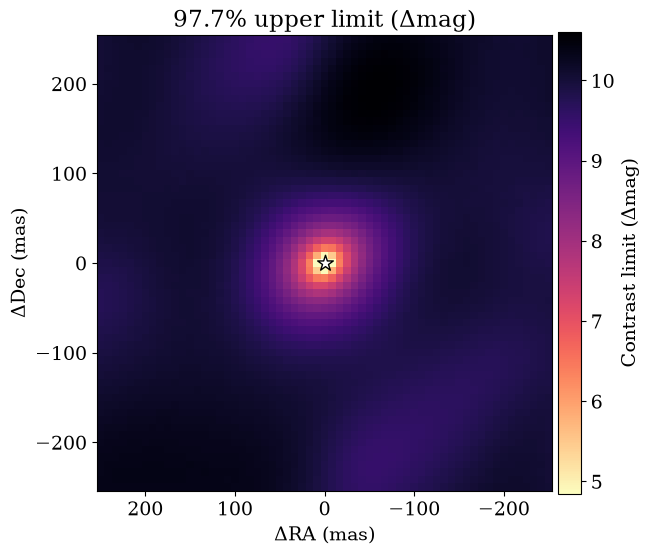

In [4]:
sigma_flux = laplace_flux_uncertainty_grid(
    BinaryModelCartesian, oidata_sim, samples, flux=opt_flux
)

# Ruffio method at the 2σ-equivalent percentile
perc = jsp.stats.norm.cdf(2.0)
ruffio_map = ruffio_upperlimit(opt_flux, sigma_flux, perc)

plot_grid_map(
    ruffio_map, samples, kind="limit", units="delta_mag", percentile=perc
);

## Absil Contrast Limits

In [Absil et al 2011](https://ui.adsabs.harvard.edu/abs/2011A%26A...535A..68A/abstract), a frequentist p-value is used to infer an upper limit from data. This is done by a chi-squared hypothesis test, inferring what the highest contrast would be such that it would have been detected at n-σ. 

/var/tmp/jobfs/virgil/src/virgil/_deprecate.py:150: RuntimeWarning: absil_limits(): 1 limits fell outside flux_bounds=(1e-06, 1.0) and were clipped to the nearer bound; pass wider flux_bounds, or None, to search further.
  return fn(*args, **kwargs)


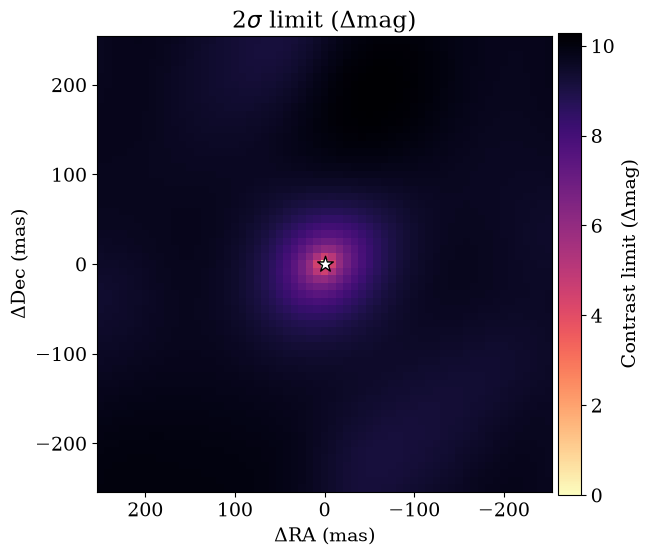

In [5]:
# Absil method at 2σ
absil_map = absil_limits(BinaryModelCartesian, oidata_sim, samples, sigma=2.0)

{
    "opt_flux_finite_frac": float(jnp.mean(jnp.isfinite(opt_flux))),
    "sigma_flux_finite_frac": float(jnp.mean(jnp.isfinite(sigma_flux))),
    "ruffio_finite_frac": float(jnp.mean(jnp.isfinite(ruffio_map))),
    "absil_finite_frac": float(jnp.mean(jnp.isfinite(absil_map))),
    "ruffio_median_dmag": float(jnp.nanmedian(flux_to_delta_mag(ruffio_map))),
    "absil_median_dmag": float(jnp.nanmedian(flux_to_delta_mag(absil_map))),
}

plot_grid_map(absil_map, samples, kind="limit", units="delta_mag", sigma=2.0);

## Contrast Curves
We can visualize these as contrast curves, and plot these on the same axis. They come out to be pretty similar but not quite identical.

The limits are companion/primary flux ratios, but by astronomical convention they are reported as a contrast (primary/companion) or in magnitudes: a companion 100 times fainter than the star has a contrast of 100, or 5 mag. `units="delta_mag"` (the default for curves) or `units="contrast"` converts for display, and `flux_to_delta_mag` / `flux_to_contrast` convert the numbers themselves.

Contrast limits say which companions a non-detection rules out at each position. To calibrate a detection threshold against simulated noise, including the look-elsewhere effect of searching a grid, and to measure a search's completeness at a fixed false-alarm probability, see [Detection ROC curves](detection_roc.md).

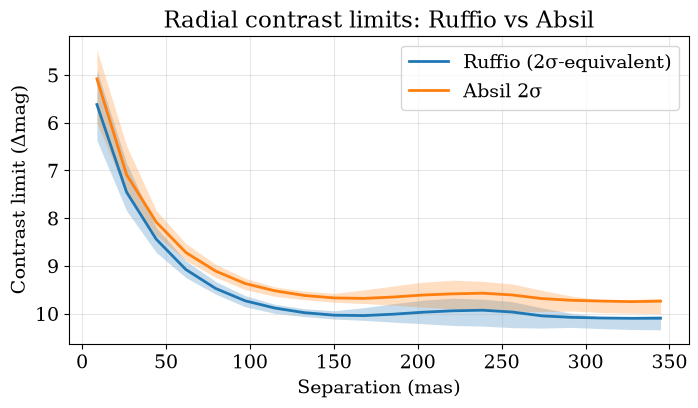

In [6]:
# Overplot Ruffio and Absil radial contrast curves on one axis
fig, ax = plt.subplots(figsize=(8, 4))
plot_contrast_curve(ruffio_map, samples, label="Ruffio (2σ-equivalent)", ax=ax)
plot_contrast_curve(absil_map, samples, label="Absil 2σ", ax=ax)
ax.set_title("Radial contrast limits: Ruffio vs Absil");

## As a pipeline

The search grid, the Absil limits and their contrast curve are the `search` and `limits` stages of [`BinaryPipeline`](pipeline.md), so running the pipeline `through="limits"` stops before the fit and the sampler, which a non-detection does not need. The cell below uses the same $\pm 250$ mas grid of 61 points per axis, the same flux axis and $\sigma = 2$. The pipeline blanks the grid points inside the resolution limit, where separation and flux are degenerate, so its limit map is compared with the hand-computed Absil map where it is defined. Its contrast curve is one of the pipeline's plots.

BinaryPipeline run in /tmp/tmpq4i2jyqe/limits_run: partial
  data.n_vis = 21
  data.n_phi = 35
  data.n_independent = 36
  data.wavel_min_m = 4.817e-06
  data.wavel_max_m = 4.817e-06
  data.baseline_min_m = 1.32
  data.baseline_max_m = 5.28001
  data.resolution_mas = 94.0887
  data.fov_mas = 752.71
  chi2.n_independent = 36
  chi2.null_reduced = 0.614164
  search.delta_chi2 = 7.05621
  search.log_bayes_factor = -0.349726
  search.max_snr = 2.65709
  search.local_nsigma = 2.65635
  search.global_nsigma = 1.91805
  search.n_trials = 7.06001
  search.dra_mas = -100
  search.ddec_mas = -175
  search.flux = 8.28444e-05
  search.max_sep_mas = 250
  limits.sigma = 2
  limits.deepest_delta_mag = 9.6868
  [pass] chi2: χ²/N = 0.614 for the star alone on quoted errors: consistent with the quoted errors.
  [warn] detection: No companion above 3σ (2.66σ local): the fit and posterior describe the highest noise peak; quote the contrast limits instead.
  [pass] grid_edge: The grid peak lies inside the

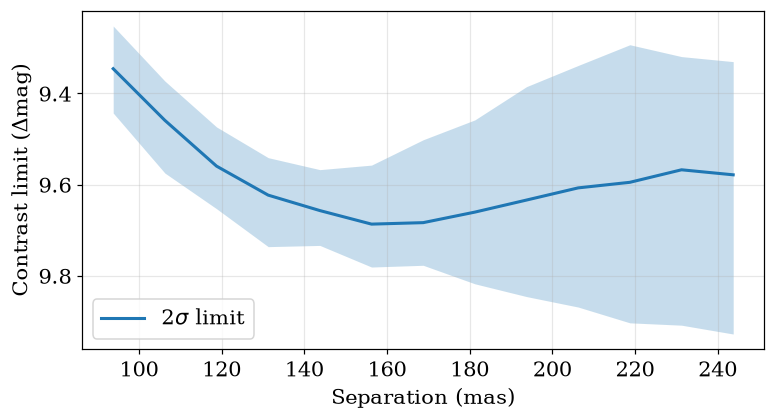

In [7]:
from tempfile import mkdtemp

from IPython.display import Image, display

from virgil.pipeline import BinaryPipeline

res = BinaryPipeline(
    oidata_sim,
    BinaryModelCartesian(dra=0.0, ddec=0.0, flux=1e-3),
    output=f"{mkdtemp()}/limits_run",
    sigma=2.0,
    max_sep_mas=250.0,
    grid_step_mas=8.34,  # 61 points from -250 to 250 mas
    flux_range=[1e-5, 10**-1.5],
    n_flux=50,
).run(through="limits")
print(res.describe())
display(Image(filename=str(res.path / "plots" / "limits_contrast_curve.png")))

In [8]:
# Hidden in the docs: where the pipeline defines a limit, it equals the
# hand-computed Absil map.
lim = onp.asarray(res.grid()["limit_flux"])
ok = onp.isfinite(lim)
print(
    "pipeline median dmag {:.2f}, deepest {:.2f}; hand-computed Absil median dmag {:.2f} (whole map)".format(
        float(onp.nanmedian(onp.asarray(res.summary["limits"]["median_delta_mag"], dtype=float))),
        res.summary["limits"]["deepest_delta_mag"],
        float(jnp.nanmedian(flux_to_delta_mag(absil_map))),
    )
)
assert ok.any()
assert onp.allclose(lim[ok], onp.asarray(absil_map)[ok], rtol=1e-3)


pipeline median dmag 9.61, deepest 9.69; hand-computed Absil median dmag 9.62 (whole map)
